In [22]:
#Imports and directory
import os
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
os.chdir("/home/ec2-user/CS-230-Deep-Learning-Project")
#os.chdir(r"C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project")
#os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

In [23]:
# Répertoire
data_dir = "data/Datasets_2"

# Charger pkl
train_df = pd.read_pickle(os.path.join(data_dir, "train_set.pkl"))
dev_df   = pd.read_pickle(os.path.join(data_dir, "dev_set.pkl"))
test_df  = pd.read_pickle(os.path.join(data_dir, "test_set.pkl"))

In [24]:
import torch
import numpy as np

# Colonnes features et target
feature_cols = ['EUR/MWh','Load_DA','Wind_DA','Solar_DA','cos_hour','sin_hour', 'cos_day','sin_day', 'cos_month', 'sin_month']
target_col = 'y'

def df_to_tensor(df, feature_cols):
    # Convert each column into a (N, 168) array, then stack along the last dimension
    arr = np.stack([np.vstack(df[col].values) for col in feature_cols], axis=2)
    return torch.tensor(arr, dtype=torch.float32)


X_train = df_to_tensor(train_df, feature_cols)
X_dev   = df_to_tensor(dev_df, feature_cols)
X_test  = df_to_tensor(test_df, feature_cols)

Y_train = torch.tensor(train_df[target_col].apply(lambda x: x[0]).values, dtype=torch.float32).unsqueeze(1)
Y_dev   = torch.tensor(dev_df[target_col].apply(lambda x: x[0]).values, dtype=torch.float32).unsqueeze(1)
Y_test  = torch.tensor(test_df[target_col].apply(lambda x: x[0]).values, dtype=torch.float32).unsqueeze(1)


# Vérification des shapes
print(X_train.shape, Y_train.shape)
print(X_dev.shape, Y_dev.shape)
print(X_test.shape, Y_test.shape)


torch.Size([63788, 168, 10]) torch.Size([63788, 1])
torch.Size([10264, 168, 10]) torch.Size([10264, 1])
torch.Size([27073, 168, 10]) torch.Size([27073, 1])


In [25]:
import torch
import torch.nn as nn

class ConvModel1(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv_layers = nn.Sequential(
            # ===== BLOCK 1 =====
            nn.Conv1d(10, 64, kernel_size=3, padding=1),  # input channels = 10
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),   # length / 2
            nn.Dropout(0.1),

            # ===== BLOCK 2 =====
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),   # length / 2
            nn.Dropout(0.1),

            # ===== BLOCK 3 =====
            nn.Conv1d(128, 168, kernel_size=3, padding=1),
            nn.BatchNorm1d(168),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1),      # collapse length to 1
            nn.Dropout(0.1)
        )

        # Fully connected layers
        self.mlp = nn.Sequential(
            nn.Linear(168, 48),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(48, 24),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(24, 6),
            nn.ReLU(),

            nn.Linear(6, 3),
            nn.ReLU(),

            nn.Linear(3, 1)  # output
        )

    def forward(self, x):
        # x shape: (batch, 168, 10)
        x = x.permute(0, 2, 1)  # -> (batch, channels=10, length=168)
        x = self.conv_layers(x) # -> (batch, 168, 1)
        x = x.squeeze(-1)       # -> (batch, 168)
        x = self.mlp(x)         # -> (batch, 1)
        return x


In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# -------------------------
# Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# Model
# -------------------------
model = ConvModel1().to(device)

# -------------------------
# He (Kaiming) initialization
# -------------------------
def init_he(m):
    if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

model.apply(init_he)

# -------------------------
# Loss + Optimizer
# -------------------------
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# LR scheduler (without verbose)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# -------------------------
# Training parameters
# -------------------------
epochs = 30
batch_size = 64

# -------------------------
# Dataloaders
# -------------------------
train_dataset = TensorDataset(X_train, Y_train)
dev_dataset   = TensorDataset(X_dev, Y_dev)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader   = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False)

# -------------------------
# Training loop
# -------------------------
train_losses = []
dev_losses = []

for epoch in range(epochs):
    # ===== TRAIN =====
    model.train()
    running_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        preds = model(X)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X.size(0)  # weighted by batch size

    train_loss = running_loss / len(train_dataset)
    train_losses.append(train_loss)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, y in dev_loader:
            X, y = X.to(device), y.to(device)
            preds = model(X)
            loss = criterion(preds, y)
            val_loss += loss.item() * X.size(0)

    dev_loss = val_loss / len(dev_dataset)
    dev_losses.append(dev_loss)

    # ===== Scheduler step + LR print =====
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(dev_loss)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != old_lr:
        print(f"Learning rate reduced: {old_lr:.1e} -> {new_lr:.1e}")

    print(f"Epoch {epoch+1}/{epochs} - Train: {train_loss:.5f} | Dev: {dev_loss:.5f}")

print("Training Finished.")


Epoch 1/30 - Train: 0.20237 | Dev: 0.33630
Epoch 2/30 - Train: 0.11718 | Dev: 0.28865
Epoch 3/30 - Train: 0.09378 | Dev: 0.29029
Epoch 4/30 - Train: 0.08248 | Dev: 0.26008
Epoch 5/30 - Train: 0.07590 | Dev: 0.26271
Epoch 6/30 - Train: 0.07027 | Dev: 0.25619
Epoch 7/30 - Train: 0.06577 | Dev: 0.27250
Epoch 8/30 - Train: 0.06274 | Dev: 0.22477
Epoch 9/30 - Train: 0.05970 | Dev: 0.24015
Epoch 10/30 - Train: 0.05806 | Dev: 0.21275
Epoch 11/30 - Train: 0.05587 | Dev: 0.24148
Epoch 12/30 - Train: 0.05471 | Dev: 0.18722
Epoch 13/30 - Train: 0.05368 | Dev: 0.24278
Epoch 14/30 - Train: 0.05164 | Dev: 0.22531
Epoch 15/30 - Train: 0.05058 | Dev: 0.21842
Learning rate reduced: 1.0e-03 -> 5.0e-04
Epoch 16/30 - Train: 0.05031 | Dev: 0.21020
Epoch 17/30 - Train: 0.04678 | Dev: 0.22360
Epoch 18/30 - Train: 0.04590 | Dev: 0.22750
Epoch 19/30 - Train: 0.04539 | Dev: 0.24665
Learning rate reduced: 5.0e-04 -> 2.5e-04
Epoch 20/30 - Train: 0.04506 | Dev: 0.26261
Epoch 21/30 - Train: 0.04337 | Dev: 0.22138
E

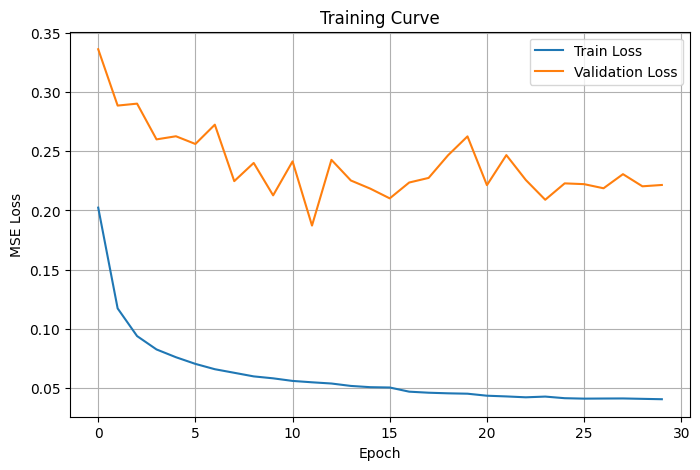

In [27]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(dev_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Curve")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# Après le training (ou à la fin de chaque epoch si tu veux)
torch.save(model.state_dict(), "convmodel1_weights.pth")
print("Model weights saved to convmodel1_weights.pth")


Model weights saved to convmodel1_weights.pth


In [29]:
# Passer le modèle en mode évaluation
model.eval()

# Fonction pratique pour faire des prédictions
def predict(model, X, device):
    model.to(device)
    X = X.to(device)
    with torch.no_grad():
        preds = model(X)
    return preds.cpu().numpy()  # renvoie numpy pour analyse ou sauvegarde

# Prédictions
train_preds = predict(model, X_train, device)
dev_preds   = predict(model, X_dev, device)
test_preds  = predict(model, X_test, device)

# Vérification
print("Train predictions shape:", train_preds.shape)
print("Dev predictions shape:  ", dev_preds.shape)
print("Test predictions shape: ", test_preds.shape)


Train predictions shape: (63788, 1)
Dev predictions shape:   (10264, 1)
Test predictions shape:  (27073, 1)


In [37]:
import numpy as np
from sklearn.metrics import mean_absolute_error

save_path = os.path.join("data/Datasets_2", "normalization_stats.pkl")
with open(save_path, "rb") as f:
    norm_stats = pickle.load(f)

means = norm_stats['means']      # pandas Series ou np.array
stds  = norm_stats['stds']
medians = norm_stats['medians']       # pandas Series ou np.array
norm_cols = norm_stats['norm_cols']

# Pour Y, supposons que c'est une seule colonne normalisée
mean_y = means[norm_cols[0]]     # si norm_cols contient le nom de Y
std_y  = stds[norm_cols[0]]
median_y = medians[norm_cols[0]]

def evaluate_predictions_from_std(y_true, y_pred, week_lag=168):
    """Renormalise y_true et y_pred puis calcule MAE et rMAE"""
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.cpu().numpy()
    y_pred = y_pred.flatten()  # s'assurer que c'est 1D
    y_true = y_true.flatten()

    # Renormalisation
    y_true = y_true * std_y + mean_y
    y_pred = y_pred * std_y + mean_y

    metrics = {}

    metrics['MAE'] = mean_absolute_error(y_true, y_pred)

    # rMAE vs previous day
    metrics['rMAE_prev'] = mean_absolute_error(y_true, y_pred) / mean_absolute_error(y_true[7:], y_true[:-7])

    # rMAE vs previous week
    metrics['rMAE_week'] = mean_absolute_error(y_true, y_pred) / mean_absolute_error(y_true[week_lag:], y_true[:-week_lag])

    # rMAE vs median
    metrics['rMAE_median'] = mean_absolute_error(y_true, y_pred) / mean_absolute_error(y_true, np.full_like(y_true, median_y))

    return metrics


In [38]:
print(median_y)

72.08


In [40]:
# -------------------------
# Générer les prédictions et calculer métriques
# -------------------------
model.eval()

def predict(model, X, device):
    X = X.to(device)
    with torch.no_grad():
        preds = model(X)
    return preds.cpu().numpy()

train_preds = predict(model, X_train, device)
dev_preds   = predict(model, X_dev, device)
test_preds  = predict(model, X_test, device)

metrics_train = evaluate_predictions_from_std(Y_train, train_preds)
metrics_dev   = evaluate_predictions_from_std(Y_dev, dev_preds)
metrics_test  = evaluate_predictions_from_std(Y_test, test_preds)

print("Train metrics:", metrics_train)
print("Dev metrics:  ", metrics_dev)
print("Test metrics: ", metrics_test)

Train metrics: {'MAE': 8.846185684204102, 'rMAE_prev': 0.5323832136051004, 'rMAE_week': 0.5145956828963956, 'rMAE_median': 0.16318594972522674}
Dev metrics:   {'MAE': 24.5717716217041, 'rMAE_prev': 0.6602927357412389, 'rMAE_week': 0.47181963340662836, 'rMAE_median': 0.2747908910276778}
Test metrics:  {'MAE': 12.98206901550293, 'rMAE_prev': 0.945232468807234, 'rMAE_week': 0.9043019472269549, 'rMAE_median': 0.32955991877914614}
